In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [6]:
df = pd.read_csv("HDD(4).csv")

In [7]:
df.head()

,Patient_ID,Age,Gender,Smoking_Habit,Diet,Family_History,Exercise_Habits,Systolic_BP,Diastolic_BP,Heart_Condition,Swelling,Dizziness,Irregular_Heart_Rate,Diagnosed_Heart_Disease
0,1,55,Male,Yes,Balanced,Yes,Moderate,130,80,Normal,No,No,No,Coronary Artery Disease
1,2,65,Female,No,High Fat,No,Sedentary,150,90,Hypertension,Yes,Yes,Yes,Heart Failure
2,3,40,Male,No,Low Fat,Yes,Active,150,70,Normal,No,No,No,Arrhythmia
3,4,70,Female,Yes,High Fat,Yes,Sedentary,150,85,Coronary Disease,Yes,Yes,Yes,Heart Attack
4,5,60,Male,No,High Fat,Yes,Moderate,140,85,Aortic Disease,Yes,No,No,Aortic Aneurysm


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Patient_ID               197 non-null    int64 
 1   Age                      197 non-null    int64 
 2   Gender                   197 non-null    object
 3   Smoking_Habit            197 non-null    object
 4   Diet                     197 non-null    object
 5   Family_History           197 non-null    object
 6   Exercise_Habits          197 non-null    object
 7   Systolic_BP              197 non-null    int64 
 8   Diastolic_BP             197 non-null    int64 
 9   Heart_Condition          197 non-null    object
 10  Swelling                 197 non-null    object
 11  Dizziness                197 non-null    object
 12  Irregular_Heart_Rate     197 non-null    object
 13  Diagnosed_Heart_Disease  197 non-null    object
dtypes: int64(4), object(10)
memory usage: 21.7

In [6]:
df.describe()

,Patient_ID,Age,Systolic_BP,Diastolic_BP
count,197.000000,197.000000,197.000000,197.000000
mean,99.000000,92.131980,139.187817,85.335025
std,57.013156,21.297045,10.802034,7.101986
min,1.000000,40.000000,120.000000,70.000000
25%,50.000000,74.000000,130.000000,81.000000
50%,99.000000,92.000000,140.000000,85.000000
75%,148.000000,110.000000,150.000000,91.000000
max,197.000000,128.000000,160.000000,102.000000


In [7]:
df.isna().sum()

Patient_ID                 0
Age                        0
Gender                     0
Smoking_Habit              0
Diet                       0
Family_History             0
Exercise_Habits            0
Systolic_BP                0
Diastolic_BP               0
Heart_Condition            0
Swelling                   0
Dizziness                  0
Irregular_Heart_Rate       0
Diagnosed_Heart_Disease    0
dtype: int64

In [8]:
df2 = pd.get_dummies(df)

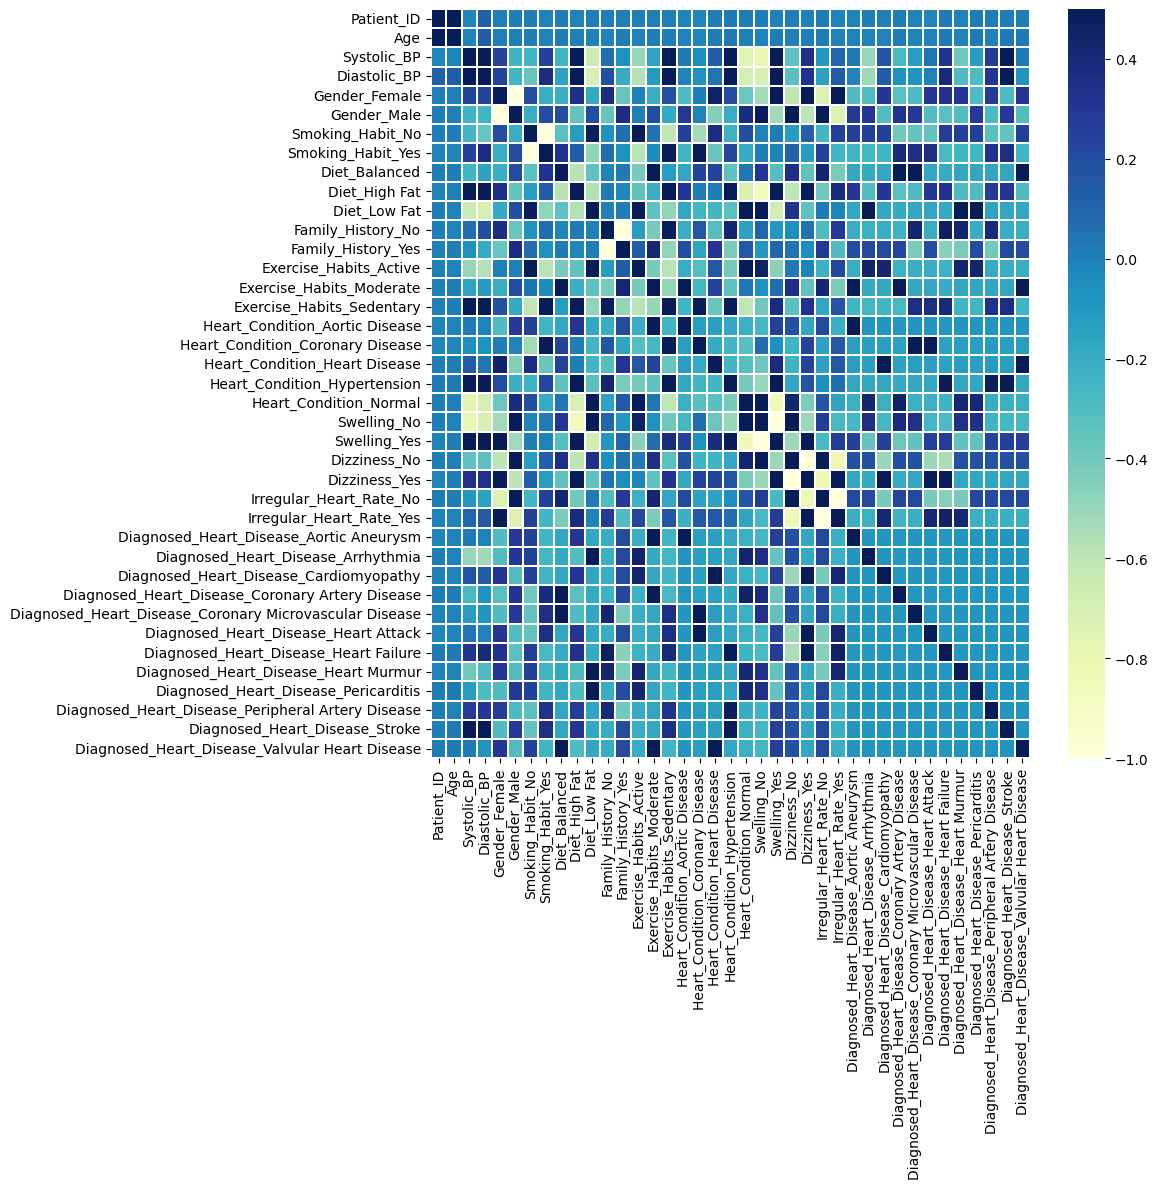

In [9]:
plt.figure(figsize=(12, 12))
sns.heatmap(df2.corr(), vmax=0.5, linewidths=0.2, cmap='YlGnBu')
plt.tight_layout()
plt.show()

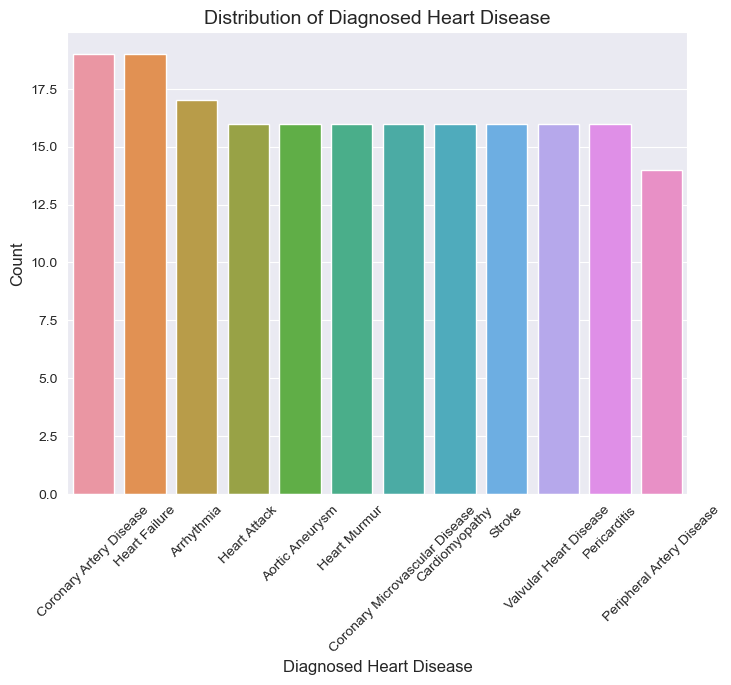

In [8]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Diagnosed_Heart_Disease', data=df)
plt.xlabel("Diagnosed Heart Disease", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of Diagnosed Heart Disease", fontsize=14)
plt.xticks(rotation=45)

plt.show()


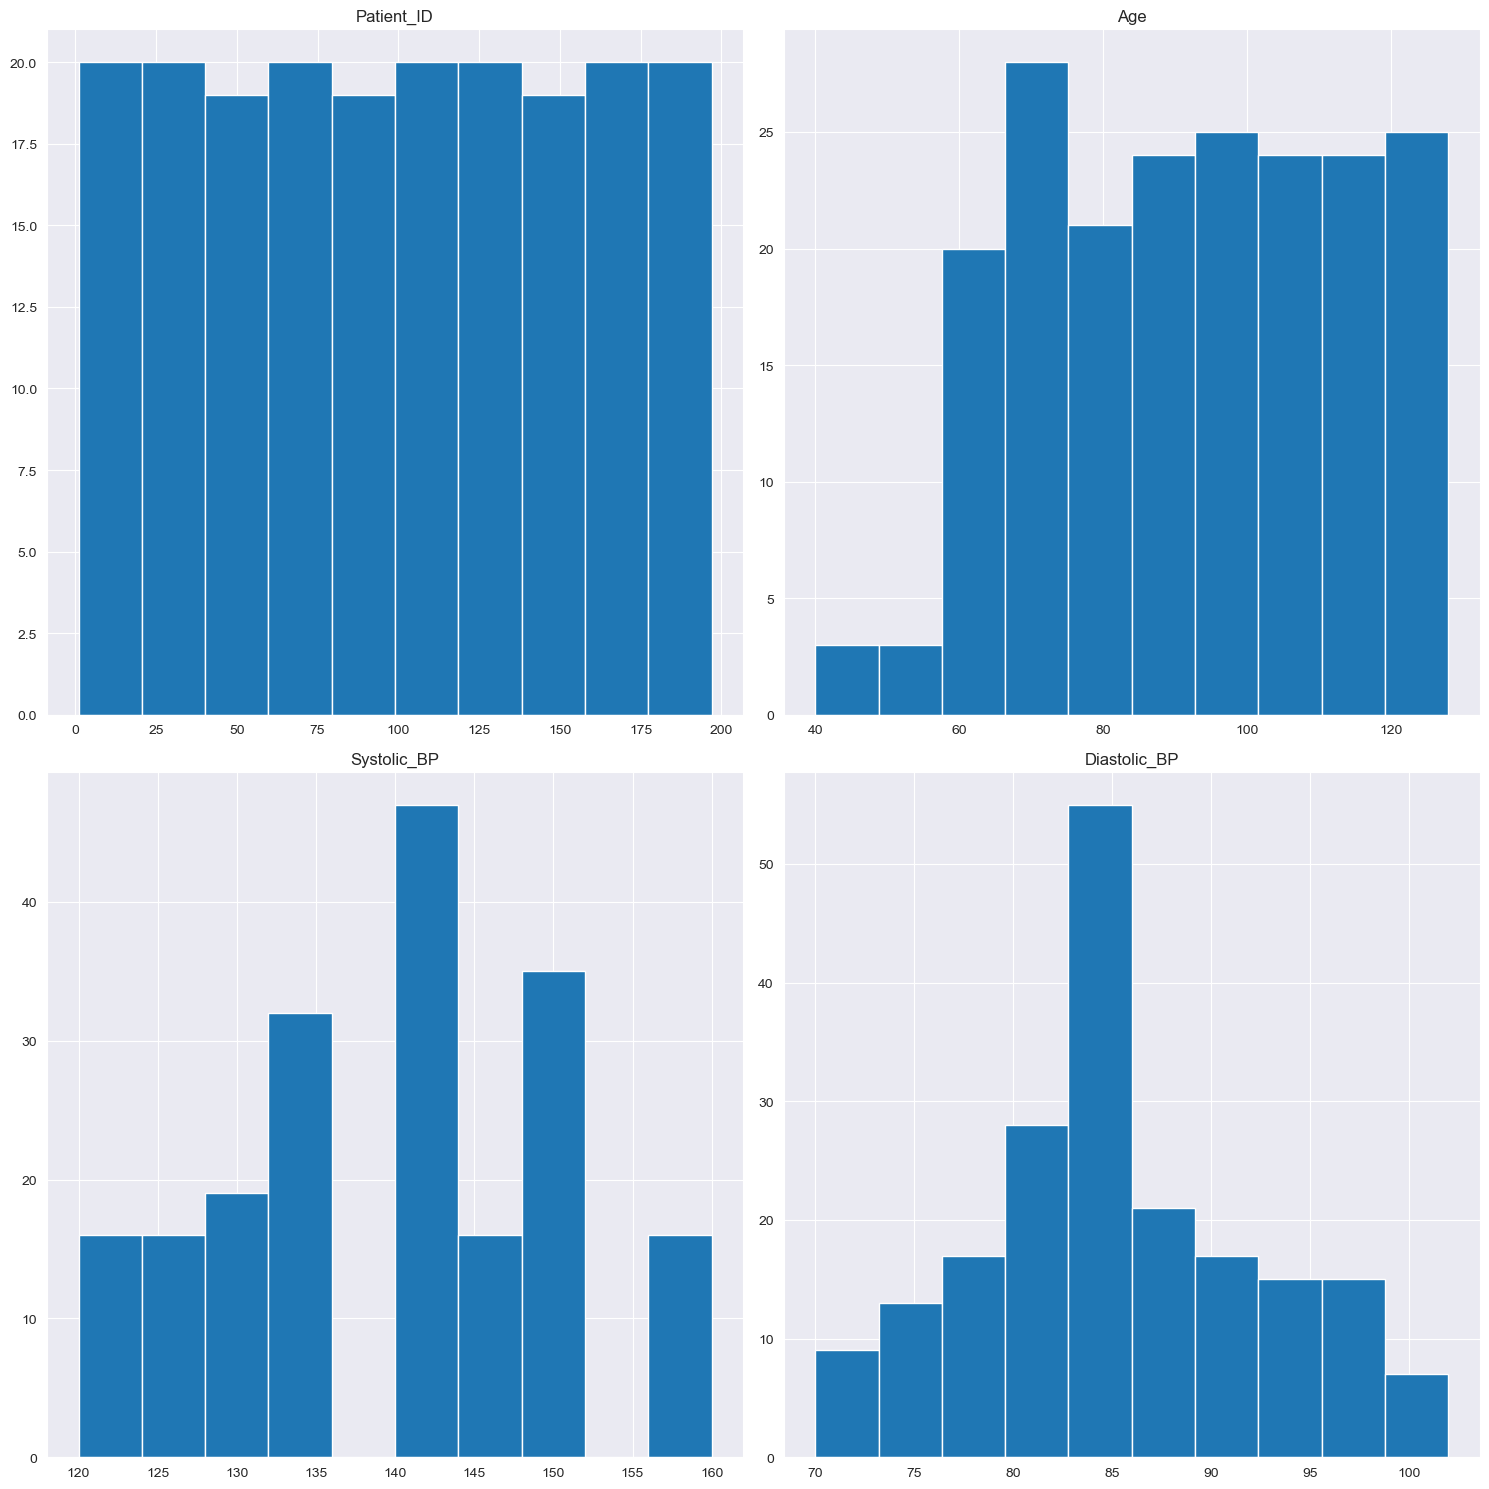

In [12]:
df.hist(figsize=(15,15))
plt.tight_layout()
plt.show()

Confusion Matrix:
[[5 0 0 0 0 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0 0 0 0 0]
 [0 0 4 0 0 0 0 0 0 0 0 0]
 [0 0 0 4 0 0 0 0 0 0 0 0]
 [0 0 0 0 5 0 0 0 0 0 0 0]
 [0 0 0 0 0 2 0 0 0 0 0 0]
 [0 0 0 0 0 0 2 0 0 0 0 0]
 [0 0 0 0 0 0 0 3 0 0 0 0]
 [0 0 0 0 0 0 0 0 3 0 0 0]
 [0 0 0 0 0 0 0 0 0 2 0 0]
 [0 0 0 0 0 0 0 0 0 0 4 0]
 [0 0 0 0 0 0 0 0 0 0 0 3]]


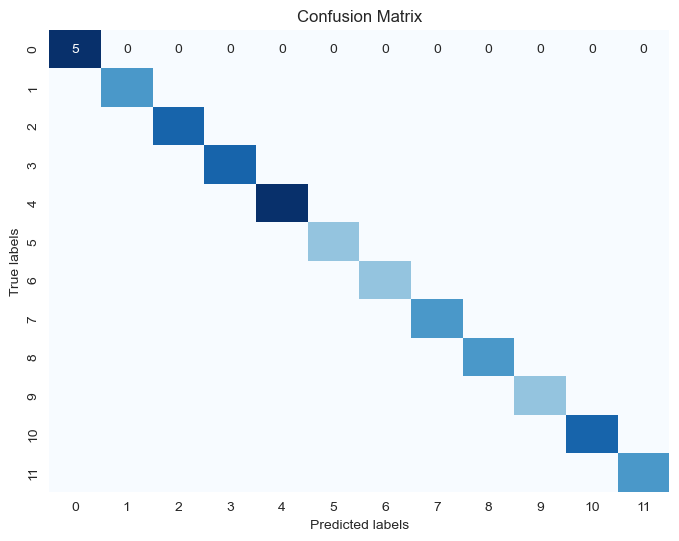

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset and train the model
df = pd.read_csv('HDD(4).csv')  # Replace 'HDD(4).csv' with the path to your dataset file

# Handle missing values if any
df.ffill(inplace=True)  # Forward fill missing values

# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=['Gender', 'Smoking_Habit', 'Diet', 'Family_History', 'Exercise_Habits', 'Heart_Condition', 'Swelling', 'Dizziness', 'Irregular_Heart_Rate'])

# Split dataset into features (X) and target variable (y)
X = df_encoded.drop('Diagnosed_Heart_Disease', axis=1)
y = df_encoded['Diagnosed_Heart_Disease']

# Train a Machine Learning Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make prediction
y_pred = model.predict(X_test)

# Calculate confusion matrix
confusion = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(confusion)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()